# Plotting PSDs

In this notebook we generate the Figure 1 and Figure 2 plots for use in the paper. The PSDs and characteristic strains have been generated in estimate_psds.sh and characteristic_strain.sh respectively, so we will load them in

In [1]:
import pycbc.psd
import numpy as np

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

paper_plot_dir = '../paper/images/dataset'

import ldc.lisa.noise.noise as ldc_noise

import sys
import os

search_dir = os.path.abspath("../search")

if search_dir not in sys.path:
    sys.path.insert(0, search_dir)

import plotting_utils


def load_psd(filename, flen, delta_f):
    return  pycbc.psd.from_txt(
        filename,
        flen,
        delta_f,
        delta_f,
        is_asd_file=False
    )



/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version 

In [2]:
# This cell contains the information about input files

estimated_format = '{channel}_sangria_hm_PSD.txt'
smoothed_estimated_format = '{channel}_sangria_hm_SMOOTHED_PSD.txt'
segment_duration = 1576800

In [3]:
# Load in PSD files
flen = 2**17
delta_f = 1e-6

A_estimate = load_psd(estimated_format.format(channel='A'), flen=flen, delta_f=delta_f)
E_estimate = load_psd(estimated_format.format(channel='E'), flen=flen, delta_f=delta_f)
T_estimate = load_psd(estimated_format.format(channel='T'), flen=flen, delta_f=delta_f)

A_smoothed = load_psd(smoothed_estimated_format.format(channel='A'), flen=flen, delta_f=delta_f)
E_smoothed = load_psd(smoothed_estimated_format.format(channel='E'), flen=flen, delta_f=delta_f)

AE_model = load_psd('model_AE_PSD.txt', flen=flen, delta_f=delta_f)
T_model = load_psd('model_T_PSD.txt', flen=flen, delta_f=delta_f)

AE_model_smoothed = load_psd('model_AE_SMOOTHED_PSD.txt', flen=flen, delta_f=delta_f)

Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.131071 Hz, available 0.100000 Hz)
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/psd/read.py:76: RuntimeWarning: divide by zero encountered in log
  slog = numpy.log(noise_data)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.131071 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.131071 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use max available frequency instead. (requested 0.131071 Hz, available 0.100000 Hz)
Requested number of samples exceeds the highest available frequency in the input data, will use m

ValueError: Invalid data in model_AE_SMOOTHED_PSD.txt

Now lets _also_ get the PSD model which doesnt include GBs - this matches the one used in the zero latency filter paper. We don't use this beyond this plot, so dont need to save it

In [ ]:

sangria_model_freqs = A_smoothed.sample_frequencies
nm_nogb = ldc_noise.get_noise_model("sangria", sangria_model_freqs, wd=False)
ae_nogb = nm_nogb.psd(option="A")
t_nogb = nm_nogb.psd(option="T")

/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:435: RuntimeWarning: divide by zero encountered in power
  return self._data ** other
/mnt/lustre2/shared_conda/envs/garethcd/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:348: RuntimeWarning: invalid value encountered in multiply
  return self._data * other


Now make the PSD plot

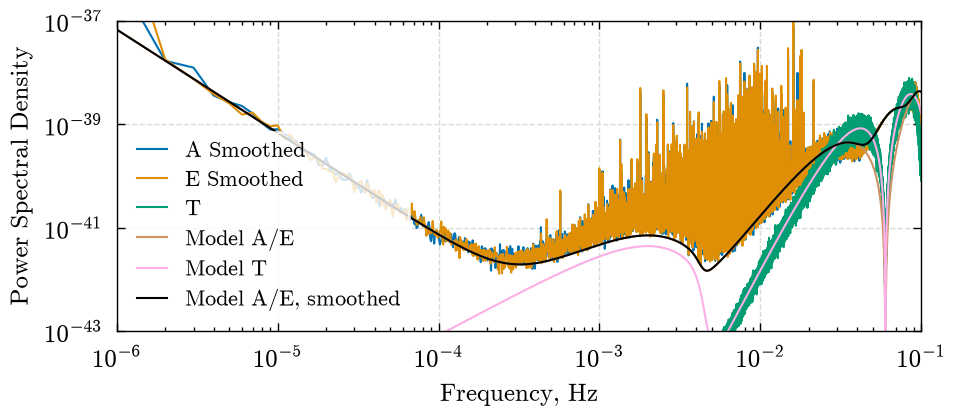

In [ ]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1]
fig, ax = plt.subplots(1, figsize=(width, height))
for fs, vals, c, label in [
    (A_smoothed.sample_frequencies, abs(A_smoothed), cycle[0], 'A Smoothed'),
    (E_smoothed.sample_frequencies, abs(E_smoothed), cycle[1], 'E Smoothed'),
    (T_estimate.sample_frequencies, abs(T_estimate), cycle[2], 'T'),
    (AE_model.sample_frequencies, abs(AE_model), cycle[5], 'Model A/E'),
    (T_model.sample_frequencies, abs(T_model), cycle[6], 'Model T'),
    (AE_model_smoothed.sample_frequencies, abs(AE_model_smoothed), 'k', 'Model A/E, smoothed'),
]:
    ax.loglog(fs, vals, c=c, label=label)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
leg1 = ax.legend(loc='lower left')
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)

## Adding pre-merger MBHB characteristic strain

But we want to get a bit more information out: do Massive black hole binaries clash with the galactic binary background when analysing them pre-merger?

So lets have a look at the charcteristic strain. First we load it in:

In [ ]:
import h5py
cutoff_days = [0.5, 1, 4, 7, 14]
example_signal_number = 2

with h5py.File('characteristic_strain/collected_characteristic_strain.hdf', 'r') as ccsf:
    freqs = ccsf['frequencies'][:]
    valid = freqs > 0
    freqs = freqs[valid]
    full_char = np.sqrt(ccsf[str(example_signal_number)]['0_A'][valid] ** 2 + ccsf[str(example_signal_number)]['0_E'][valid] ** 2)
    char = {
        days: np.sqrt(ccsf[str(example_signal_number)][str(days).replace('.','p') + '_A'][valid] ** 2 + 
                      ccsf[str(example_signal_number)][str(days).replace('.','p') + '_E'][valid] ** 2)
        for days in cutoff_days
    }


time_before_colors = plotting_utils.get_colors(cutoff_days)
time_before_colors[0] = 'k'

Now plot on its own to check that it looks sensible. Note that we are transforming compared to the previous notebook so that it can sit on the same plot as the PSDs. Add in the plots with the pre-merger cutoffs.

(3e-43, 1e-35)

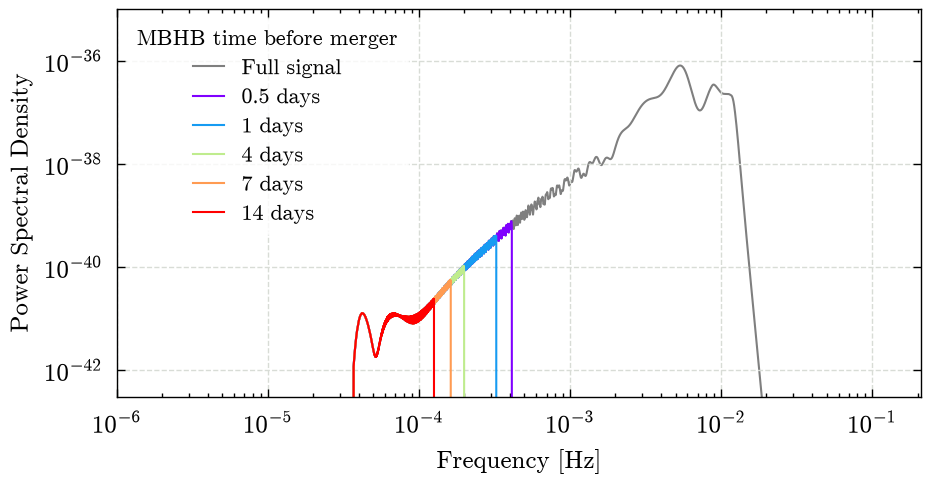

In [ ]:
width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))

ax.loglog(
    freqs,
    full_char ** 2 / freqs,
    c='k',
    label='Full signal',
    zorder=-100,
    alpha=0.5
)
for days in cutoff_days:

    ax.loglog(
        freqs,
        char[days] ** 2 / freqs,
        color=time_before_colors[days],
        label=f'{days} days',
    )

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency [Hz]")
ax.grid()
ax.legend(title='MBHB time before merger', loc='upper left')
ax.set_xlim(left=1e-6)
ax.set_ylim([3e-43, 1e-35])

# PSDs money plot

Now lets have a look at the PSDS plotted together with the characteristic strains

In [ ]:
width = plt.rcParams["figure.figsize"][0] * 2
height = plt.rcParams["figure.figsize"][1] * 1.5
fig, ax = plt.subplots(1, figsize=(width, height))

# PSD curves
psd_curves = [
    (A_estimate.sample_frequencies, A_estimate, "tab:orange", 'A Estimated', 10),
    (T_estimate.sample_frequencies, T_estimate, "tab:blue", 'T Estimated', 6),
    (AE_model.sample_frequencies, AE_model, "tab:green", 'Model A/E', 30),
    (T_model.sample_frequencies, T_model, "tab:red", 'Model T', 25),
]
for fs, vals, c, label, z in psd_curves:
    ax.loglog(fs, vals, c=c, label=label, zorder=z)

# Smoothed sections (already restricted to 3e-2 - 1e-1 Hz)
select_freqs = np.logical_and(
    A_smoothed.sample_frequencies > 3e-2,
    A_smoothed.sample_frequencies < 9e-2,
)
ax.loglog(
    A_smoothed.sample_frequencies[select_freqs],
    A_smoothed[select_freqs],
    c="tab:brown",
    label='A Smoothed',
    zorder=15
)


ax.loglog(
    sangria_model_freqs,
    ae_nogb,
    c='k',
    linestyle=':',
    label='Model A/E, no GB',
    zorder=35
)

select_freqs = np.logical_and(
    AE_model_smoothed.sample_frequencies > 3e-2,
    AE_model_smoothed.sample_frequencies < 1e-1
)
ax.loglog(
    AE_model_smoothed.sample_frequencies[select_freqs],
    AE_model_smoothed[select_freqs],
    c='k',
    linestyle='--',
    label='Model A/E, smoothed',
    zorder=40
)
ax.axvspan(
    3e-2,
    1e-1,
    color='gray',
    alpha=0.2,
    zorder=-30,
    label="Smoothed Section"
)

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
leg1 = ax.legend(loc='upper left', frameon=True)
leg1.set_zorder(100)
line2 = []
labels2 = []

ax.loglog(
    freqs,
    full_char ** 2 / freqs,
    c='k',
    zorder=-100
)
line2.append(
    ax.loglog(
        [],
        [],
        color='k',
    )[0]
)
labels2.append('Full Signal')
for days in cutoff_days:

    ax.loglog(
        freqs,
        char[days] ** 2 / freqs,
        color=time_before_colors[days],
        label=f'{days} days',
        zorder=40+days
    )
    line2.append(
        ax.loglog(
            [],
            [],
            color=time_before_colors[days],
        )[0]
    )
    labels2.append(f'{days} days' if days > 0 else 'Full Signal')

leg2 = ax.legend(
    line2,
    labels2,
    loc="center left",
    title=f"Pre-merger MBHB Characteristic Strain\n(Signal {example_signal_number})",
    bbox_to_anchor=(1.05,0.5),
)
ax.add_artist(leg1)
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-5, 1e-1])
ax.grid(zorder=5)

fig.savefig(f'{paper_plot_dir}/figure_1_psds_with_sources.png')

NameError: name 'plt' is not defined

Well thats nice, until around 3-4 days before merger, (for this signal) the MBHB strain is completely separate from the galactic binary foreground. Even at 0-5 & 1 day before merger, it is well below the MBHB signal.

This is important to show that this isnt a 'global fit' problem, and we can do this search without significantly worrying about removing the galactic white dwarf binary foregound from the data 🥳🎉🎊

## Load and plot the "smoothing section"

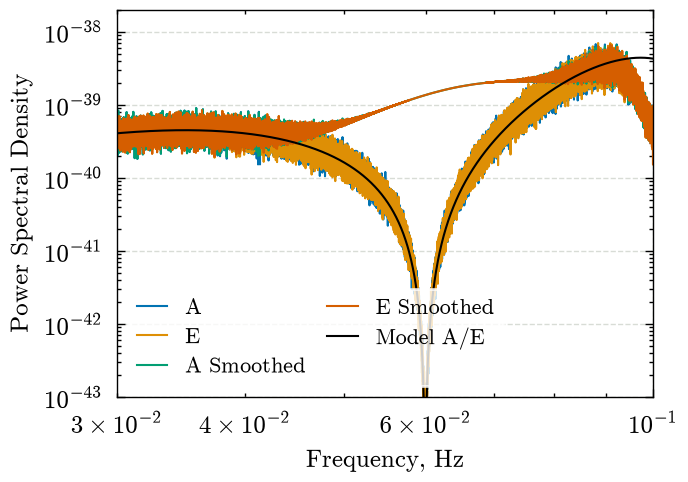

: 

In [ ]:



width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
# Lets plot the PSDs to compare them:
fig, ax = plt.subplots(1, figsize=(width, height))

ax.loglog(
    A_estimate.sample_frequencies,
    A_estimate,
    label='A',
    color=cycle[0]
)
ax.loglog(
    E_estimate.sample_frequencies,
    E_estimate,
    label='E',
    color=cycle[1]
)
ax.loglog(
    A_smoothed.sample_frequencies,
    A_smoothed,
    label='A Smoothed',
    color=cycle[2]
)
ax.loglog(
    E_smoothed.sample_frequencies,
    E_smoothed,
    label='E Smoothed',
    color=cycle[3]
)
ax.loglog(
    AE_model.sample_frequencies,
    AE_model,
    label='Model A/E',
    color='k'
)
# ax.loglog(
#     sangria_model_freqs[pks],
#     sangria_model_ae_withgb[pks],
#     color='k',
#     linestyle='--',
#     marker='x',
#     label='Model A/E peaks'
# )
# ax.loglog(
#     smoothed_freqs,
#     model_line * windows.hann(model_line.size),
#     label='Windowed smoothing model',
#     linestyle='--',
#     c='k',
# )
# ax.loglog(
#     sangria_model_freqs,
#     modelled_psd_smoothed,
#     label='Model A/E, smoothed',
#     linestyle='--',
#     color='y'
# )

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
ax.legend(loc='lower left', ncol=2)
ax.set_ylim([1e-43, 2e-38])
ax.set_xlim([3e-2, 1e-1])
ax.grid(zorder=-100)

fig.savefig(f'{paper_plot_dir}/figure_2_smoothing_60mHz.png')